## Second Class

In [11]:
%pip install pandas numpy seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-macosx_10_15_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl (64 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━

In [12]:
%pip list

Package                   Version
------------------------- -----------
anyio                     4.14.2
appnope                   1.0.0
argon2-cffi               25.1.0
argon2-cffi-bindings      26.1.0
arrow                     1.4.0
asttokens                 3.0.2
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
beautifulsoup4            4.15.0
bleach                    6.4.0
certifi                   2026.7.22
cffi                      2.1.1
charset-normalizer        3.5.1
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.21
defusedxml                0.7.1
executing                 2.2.1
fastjsonschema            2.22.2
fonttools                 4.63.0
fqdn                      1.5.1
h11                       0.16.0
httpcore                  1.0.9
httpx                     0.28.1
idna                      3.19
ipykernel                 7.3.0
ipython          

In [16]:
import pandas as pd
import numpy as np

In [17]:
%matplotlib inline

## Reading Data From a CSV File
Read in a file containing data from hERG assays in the ChEMBL database

In [19]:
%pip install --upgrade certifi


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [21]:
import ssl, certifi, urllib.request
import pandas as pd

url = "https://raw.githubusercontent.com/PatWalters/practical_cheminformatics_tutorials/main/data/ChEMBL_hERG.csv"

ctx = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(url, context=ctx) as resp:
    df = pd.read_csv(resp)

Examine the number of rows and columns in the dataframe

In [22]:
df.shape

(8989, 13)

### Getting an Overview of the Data
We can also look at datatype for each of the columns

In [24]:
df.dtypes

canonical_smiles         str
molregno               int64
mol_chembl_id            str
standard_relation        str
standard_value       float64
standard_type            str
standard_units           str
description              str
organism                 str
assay_type               str
confidence_score       int64
pref_name                str
tgt_chembl_id            str
dtype: object

In [25]:
df.columns

Index(['canonical_smiles', 'molregno', 'mol_chembl_id', 'standard_relation',
       'standard_value', 'standard_type', 'standard_units', 'description',
       'organism', 'assay_type', 'confidence_score', 'pref_name',
       'tgt_chembl_id'],
      dtype='str')

The "describe" method provides summary statistics for numeric columns. 

In [26]:
df.describe()

,molregno,standard_value,confidence_score
count,8.989000e+03,8.989000e+03,8989.000000
mean,1.162010e+06,9.680188e+05,8.944599
std,6.612153e+05,2.558712e+07,0.228774
min,9.700000e+01,1.400000e-01,8.000000
25%,5.569920e+05,1.880000e+03,9.000000
50%,1.280901e+06,9.400000e+03,9.000000
75%,1.748621e+06,2.900000e+04,9.000000
max,2.196506e+06,1.000000e+09,9.000000


## Converting Datatypes
Note that Pandas thinks that the molregno column is an integer. This is not what we want, we want this column to be a string. Let's fix it.



In [28]:
df.molregno = df.molregno.apply(str)
df.dtypes

canonical_smiles         str
molregno                 str
mol_chembl_id            str
standard_relation        str
standard_value       float64
standard_type            str
standard_units           str
description              str
organism                 str
assay_type               str
confidence_score       int64
pref_name                str
tgt_chembl_id            str
dtype: object

### Finding Duplicate Molecules
Recall that our dataframe contains 8989 rows.  Let's see how many unique molregno values are in the dataframe.  Duplicate molregno values will be same molecule, so we'll average the values for those molecules.

In [29]:
len(df.molregno.unique())

7438

### Examining Assay Types
The dataframe contains two types of assays, binding assays (B), and functional assays (F).  Let's make a bar chart to see how many of each are in the dataframe. 

<Axes: xlabel='assay_type'>

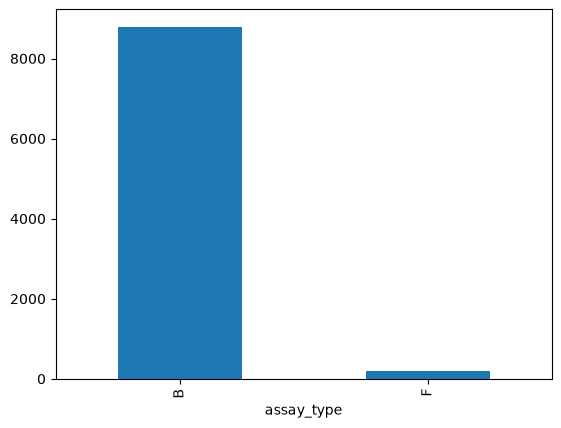

In [30]:
df.assay_type.value_counts().plot(kind='bar')

We will limit our analysis to only binding assays.

In [31]:
df = df.query("assay_type == 'B'")
df.shape

(8791, 13)

## Aggregating Data
In order to combine rows that contain the same molecule, we will use the "groupby" function.

In [35]:
gb = df.groupby("molregno")

We will iterate over the groups add the name and the mean of the multiple replicates to a temporary_list. Once this is finished we will create a new dataframe with the molecule name and the average IC50.

In [36]:
row_list = []
for k,v in gb:
    row_list.append([k,v.standard_value.mean()])
row_df = pd.DataFrame(row_list,columns=["name","standard_value"])

Let's see how many rows and columns are in our new dataframe.  Note that this is the same as the number of unique values of molregno. 

In [37]:
row_df.shape

(7382, 2)

## Examining the Data Distribution
Now we will make a plot of the distribution of IC50 values. To do this, we will use the Seaborn Python library.

In [38]:
import seaborn as sns

First we will set a few variables to make the plots look better.

In [39]:
sns.set(rc={'figure.figsize': (15, 12)})
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

Now we can make the plot.

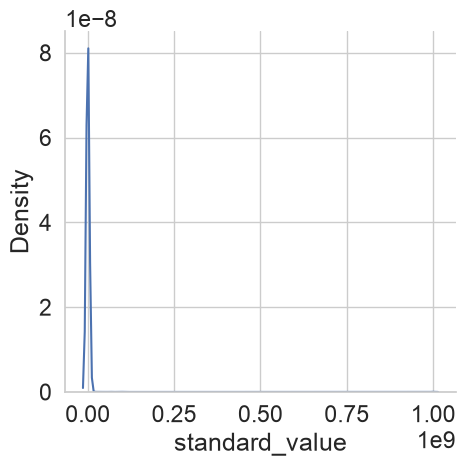

In [41]:
ax = sns.displot(row_df.standard_value,kind="kde")

Note that the plot above isn't very informative.  Most over the values are small, but there are some large values that are skewing the scale on the x-axis.   Let's plot the pIC50, which is the negative log of the IC50.  To do this, we'll first create a column containing the pIC50. 

In [42]:
row_df["pIC50"] = -np.log10(row_df.standard_value * 1e-9)

In [43]:
row_df.head()

,name,standard_value,pIC50
0,10358,16934.368,4.771231
1,1037723,130.000,6.886057
2,1038161,700.000,6.154902
3,1038163,20000.000,4.698970
4,1038164,20000.000,4.698970


Let's make another plot, this time we'll plot the pIC50 distribution.

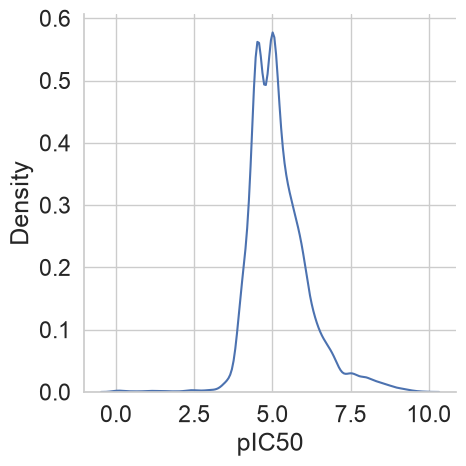

In [44]:
ax = sns.displot(row_df.pIC50,kind="kde")

## Checking For Null Values
Check the dataframe to see if we have any null values.

In [46]:
row_df.dropna().shape

(7382, 3)

In [47]:
row_df.shape

(7382, 3)

The shapes of the data frame and the dataframe without null values are the same, so we're good. 

### Sorting the Data
Sort the data by pIC50, note that the values with pIC50 approximately equal to zero (the first few rows) are almost certainly data input errors.  These compounds are reported to have IC50s of 10^9nM, which is 1M.  I seriously doubt that the compounds would even be soluble at that concentration.

In [48]:
row_df.sort_values("pIC50",ascending=True).head()

,name,standard_value,pIC50
3066,1758382,1.000000e+09,-0.00
3065,1758380,1.000000e+09,-0.00
3067,1758385,1.000000e+09,-0.00
5531,440049,9.549926e+08,0.02
5545,440263,7.585776e+08,0.12


## Selecting High Confidence Data
Let's look at the distribution of confidence scores associated with our original dataset.

In [49]:
df.confidence_score.value_counts()

confidence_score
9    8395
8     396
Name: count, dtype: int64

We will create a new dataframe with only the molecules have a confidence score of 9.

In [50]:
score_9 = df.query("confidence_score == 9")

In [51]:
score_9.shape

(8395, 13)

Let's try to add a column to the new dataframe that we created. Note that this triggers a SettingWithCopyWarning, because the new dataframe is just a reference to a slice of the original dataframe and the assignment may not behave as expected.

In [53]:
score_9["extra"] = 3

What we really want to do is create a new dataframe, we can do this with the "copy" method.

In [54]:
score_9 = df.query("confidence_score == 9").copy()

Now adding a new column works.

In [55]:
score_9['extra'] = 3

In [56]:
score_9.head()

,canonical_smiles,molregno,mol_chembl_id,standard_relation,standard_value,standard_type,standard_units,description,organism,assay_type,confidence_score,pref_name,tgt_chembl_id,extra
46,COC(=O)C1=C(C)NC(=C(C1c2ccccc2[N+](=O)[O-])C(=...,419596,CHEMBL193,=,50118.72,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,3
47,CN(CCOc1ccc(NS(=O)(=O)C)cc1)CCc2ccc(NS(=O)(=O)...,5638,CHEMBL473,=,10.00,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,3
48,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc4cccnc24)CC1,110803,CHEMBL998,=,169.82,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,3
49,Oc1ccc(CCN2CCC(CC2)Nc3nc4ccccc4n3Cc5ccc(F)cc5)cc1,91240,CHEMBL60796,=,1.00,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,3
50,Cc1[nH]cnc1CN2CCc3c(C2=O)c4ccccc4n3C,153342,CHEMBL1110,=,3235.94,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,3


Let's say that we want to create a new column with more descriptive names for the data quality.  We can do this using the "map" function. 


In [57]:
level_map = {8: 'fair', 9: 'good'}
df['confidence_level'] = df.confidence_score.map(level_map)

In [58]:
df.head()

,canonical_smiles,molregno,mol_chembl_id,standard_relation,standard_value,standard_type,standard_units,description,organism,assay_type,confidence_score,pref_name,tgt_chembl_id,confidence_level
46,COC(=O)C1=C(C)NC(=C(C1c2ccccc2[N+](=O)[O-])C(=...,419596,CHEMBL193,=,50118.72,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,good
47,CN(CCOc1ccc(NS(=O)(=O)C)cc1)CCc2ccc(NS(=O)(=O)...,5638,CHEMBL473,=,10.00,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,good
48,CCOC(=O)N1CCC(=C2c3ccc(Cl)cc3CCc4cccnc24)CC1,110803,CHEMBL998,=,169.82,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,good
49,Oc1ccc(CCN2CCC(CC2)Nc3nc4ccccc4n3Cc5ccc(F)cc5)cc1,91240,CHEMBL60796,=,1.00,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,good
50,Cc1[nH]cnc1CN2CCc3c(C2=O)c4ccccc4n3C,153342,CHEMBL1110,=,3235.94,IC50,nM,Inhibition of human Potassium channel HERG exp...,Homo sapiens,B,9,HERG,CHEMBL240,good


In [ ]:
We can make a bar plot of the data quality with the descriptions on the x-axis.

